
TABELA COMPARATIVA
   n | Tempo médio (s) | Geracoes médias | Taxa sucesso (%)
-----------------------------------------------------------------------------------------------
   8 |          0.0027 |            5.60 |           100.00
  15 |          0.0715 |           47.93 |            10.00
  20 |          0.1310 |           50.00 |             3.33
  30 |          0.2950 |           50.00 |             0.00


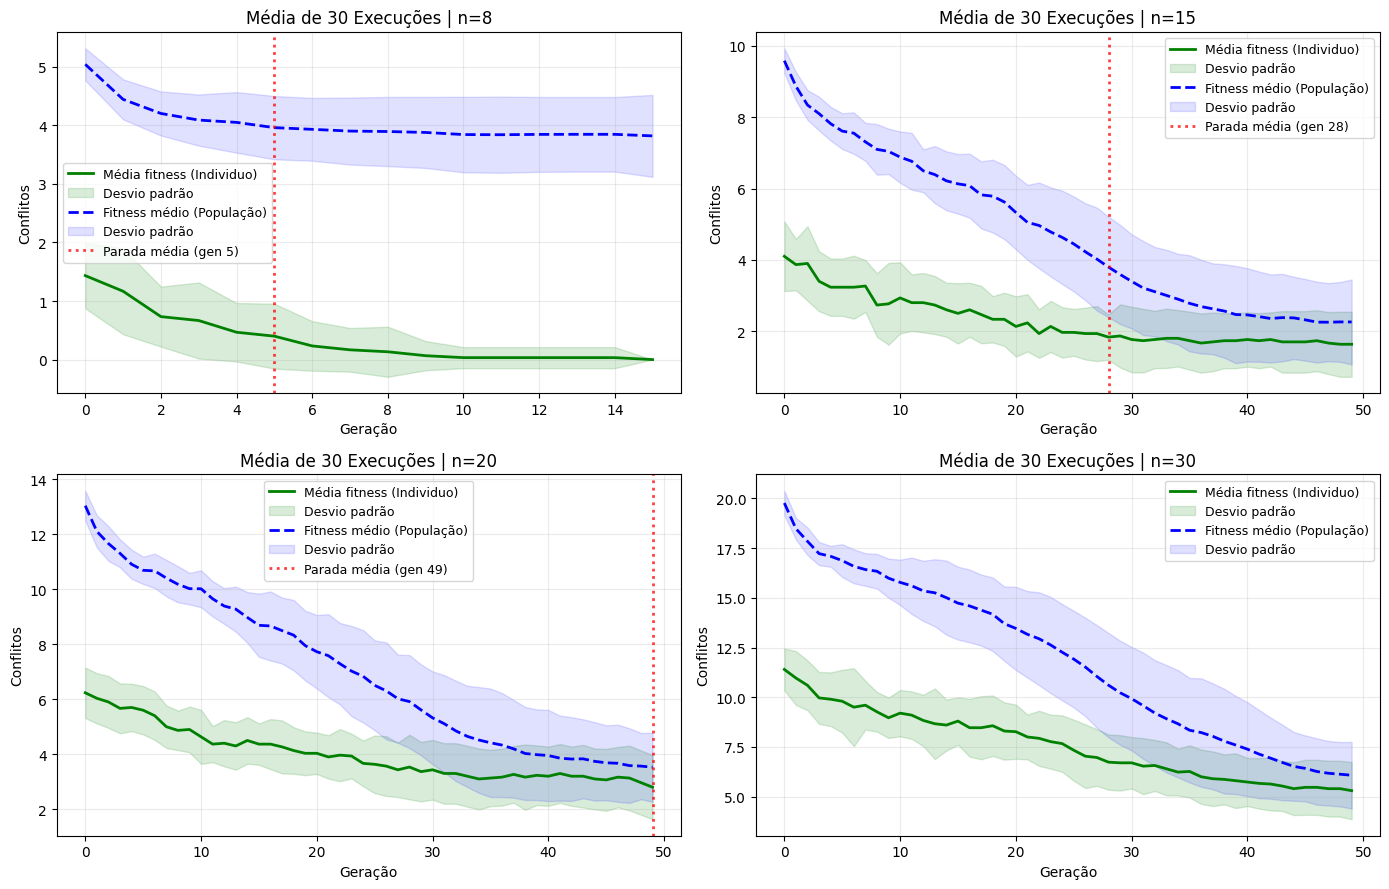

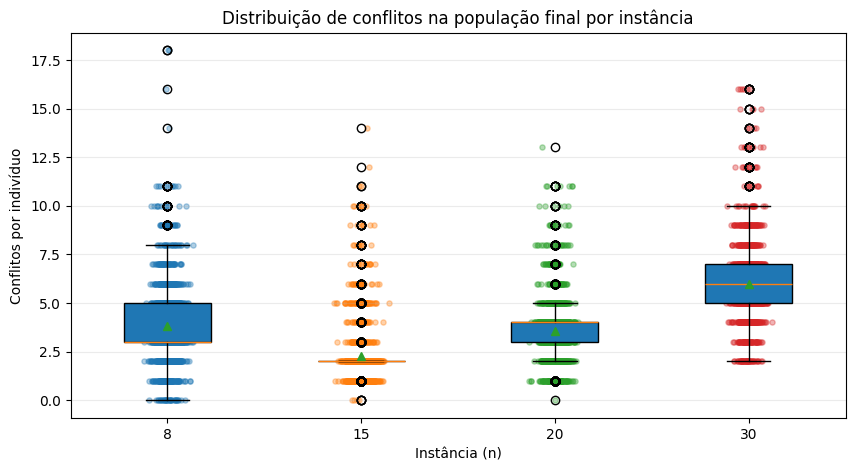

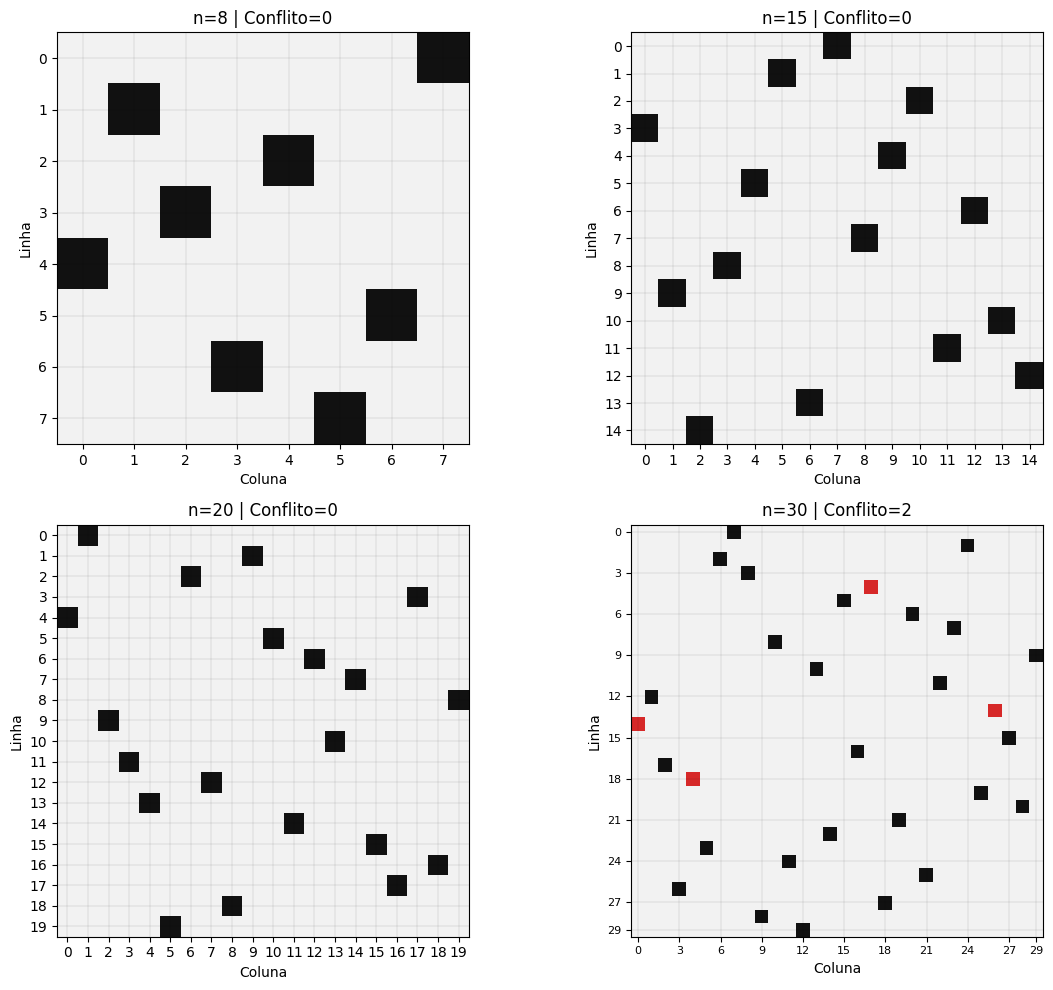

In [13]:
# !pip install numpy matplotlib
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

instancias=[8, 15, 20, 30]
qtd_execucoes = 30

class AG_N_Rainhas:
    def __init__(self, n, tamanho_populacao=50, max_geracoes=50, taxa_mutacao=0.05):
        self.n = n
        self.tamanho_populacao = tamanho_populacao
        self.max_geracoes = max_geracoes
        self.taxa_mutacao = taxa_mutacao
        self.populacao = self._inicializar_populacao()

    def _inicializar_populacao(self): # gera população inicial aleatória
        pop = []
        for _ in range(self.tamanho_populacao):
            individuo = list(range(self.n))
            random.shuffle(individuo) # vetor de permutaçao
            pop.append(individuo)
        return pop

    def calcular_aptidao(self, individuo, retornar_linhas=False): # calcula conflitos em diagonais
        conflitos = 0
        linhasconflito = set()
        for i in range(len(individuo)):
            for j in range(i + 1, len(individuo)):
                if abs(i - j) == abs(individuo[i] - individuo[j]): # (L1 - L2) = (C1 - C2)
                    conflitos += 1
                    if retornar_linhas:
                        linhasconflito.add(i)
                        linhasconflito.add(j)
        if retornar_linhas:
            return conflitos, linhasconflito
        return conflitos

    def selecao_torneio(self):
        competidor1 = random.choice(self.populacao)
        competidor2 = random.choice(self.populacao)

        if self.calcular_aptidao(competidor1) < self.calcular_aptidao(competidor2):
            return competidor1
        return competidor2 # retorna o melhor

    def cruzamento(self, pai1, pai2):
        ponto = random.randint(1, self.n - 2)
        filho = pai1[:ponto] + [gene for gene in pai2 if gene not in pai1[:ponto]]
        return filho

    def mutacao(self, individuo): #sortei a mutaçao por troca de posições
        if random.random() < self.taxa_mutacao:
            idx1, idx2 = random.sample(range(self.n), 2)
            individuo[idx1], individuo[idx2] = individuo[idx2], individuo[idx1]
        return individuo

    def executa(self, verbose=False):
        historico_melhor = []
        historico_media = []
        geracao_parada = None

        for geracao in range(self.max_geracoes):
            # tem conflitos de todos os indivíduos?
            aptidoes_atuais = [self.calcular_aptidao(ind) for ind in self.populacao]

            melhor_valor = min(aptidoes_atuais)
            media_valor = sum(aptidoes_atuais) / self.tamanho_populacao

            historico_melhor.append(melhor_valor)
            historico_media.append(media_valor)

            if melhor_valor == 0:
                if verbose:
                    print(f"Solução ótima encontrada na geração {geracao}!")
                geracao_parada = geracao
                break

            # atualização geração da nova população
            nova_populacao = []
            for _ in range(self.tamanho_populacao):
                p1 = self.selecao_torneio()
                p2 = self.selecao_torneio()
                filho = self.cruzamento(p1, p2)
                filho = self.mutacao(filho)
                nova_populacao.append(filho)

            # filhos substituem os pais
            self.populacao = nova_populacao

        indice_melhor = np.argmin([self.calcular_aptidao(ind) for ind in self.populacao])
        melhor_individuo = self.populacao[indice_melhor]

        return melhor_individuo, historico_melhor, historico_media, geracao_parada


def executa_experimentos(instancias, repeticoes=qtd_execucoes):
    resultados = {}

    for n in instancias:
        dados_n = {
            "conflitos_finais": [], 
            "conflitos_pop_final": [], 
            "geracoes": [], 
            "tempos": [], 
            "geracoes_parada": [], 
            "melhor_hists": [], 
            "media_hists": [], 
            "melhor_hist": None, 
            "media_hist": None, 
            "melhor_individuo": None, 
            "melhor_conflito": float("inf"),
        }

        for _ in range(repeticoes):
            ag = AG_N_Rainhas(n=n)

            t0 = time.perf_counter() # tempo
            melhor_solucao, hist_melhor, hist_media, geracao_parada = ag.executa(verbose=False)
            tempo_exec = time.perf_counter() - t0

            conflito_final = hist_melhor[-1]
            dados_n["conflitos_finais"].append(conflito_final)
            dados_n["conflitos_pop_final"].extend([ag.calcular_aptidao(ind) for ind in ag.populacao])
            dados_n["geracoes"].append(len(hist_melhor))
            dados_n["tempos"].append(tempo_exec)
            dados_n["geracoes_parada"].append(geracao_parada if geracao_parada is not None else ag.max_geracoes)
            dados_n["melhor_hists"].append(hist_melhor)
            dados_n["media_hists"].append(hist_media)

            if conflito_final < dados_n["melhor_conflito"]:
                dados_n["melhor_conflito"] = conflito_final
                dados_n["melhor_hist"] = hist_melhor
                dados_n["media_hist"] = hist_media
                dados_n["melhor_individuo"] = melhor_solucao

        resultados[n] = dados_n

    return resultados


def imprime_tabela_comparativa(resultados):
    print("\n" + "=" * 95)
    print("TABELA COMPARATIVA")
    print("=" * 95)
    print(f"{'n':>4} | {'Tempo médio (s)':>15} | {'Geracoes médias':>15} | {'Taxa sucesso (%)':>16}")
    print("-" * 95)

    for n in sorted(resultados.keys()):
        dados = resultados[n]
        tempo_medio = float(np.mean(dados["tempos"]))
        geracoes_medias = float(np.mean(dados["geracoes"]))
        taxa_sucesso = float(np.mean(np.array(dados["conflitos_finais"]) == 0) * 100)

        print(f"{n:>4} | {tempo_medio:>15.4f} | {geracoes_medias:>15.2f} | {taxa_sucesso:>16.2f}")

#usei IA para me ajudar a plotar o grafico diante os dados estatisticos que eu obtive ao desenvolver o algoritmo genetico do problema e assim melhor representando para a analise
def plota_convergencia(resultados):
    itens = sorted(resultados.items())
    qtd = len(itens)
    cols = 2
    rows = int(np.ceil(qtd / cols))

    fig, axs = plt.subplots(rows, cols, figsize=(14, 4.5 * rows), sharex=False, sharey=False)
    axs = np.array(axs).reshape(-1)

    for i, (n, dados) in enumerate(itens):
        max_len = max(len(h) for h in dados["melhor_hists"])

        melhor_mat = np.array([
            h + [h[-1]] * (max_len - len(h)) for h in dados["melhor_hists"]
        ], dtype=float)
        media_mat = np.array([
            h + [h[-1]] * (max_len - len(h)) for h in dados["media_hists"]
        ], dtype=float)

        melhor_media = melhor_mat.mean(axis=0)
        melhor_std = melhor_mat.std(axis=0)
        pop_media = media_mat.mean(axis=0)
        pop_std = media_mat.std(axis=0)
        x = np.arange(max_len)

        axs[i].plot(x, melhor_media, color="green", linewidth=2, label="Média fitness (Individuo)")
        axs[i].fill_between(
            x,
            melhor_media - melhor_std,
            melhor_media + melhor_std,
            color="green",
            alpha=0.15,
            label="Desvio padrão"
        )

        axs[i].plot(x, pop_media, color="blue", linestyle="--", linewidth=2, label="Fitness médio (População)")
        axs[i].fill_between(
            x,
            pop_media - pop_std,
            pop_media + pop_std,
            color="blue",
            alpha=0.12,
            label="Desvio padrão"
        )

        paradas = [g for g in dados["geracoes_parada"] if g < max_len]
        if paradas:
            parada_media = int(round(np.mean(paradas)))
            axs[i].axvline(
                x=parada_media,
                color="red",
                linestyle=":",
                linewidth=2,
                alpha=0.75,
                label=f"Parada média (gen {parada_media})"
            )

        tempo_medio = np.mean(dados["tempos"])
        rep = len(dados["tempos"])
        axs[i].set_xlabel("Geração")
        axs[i].set_title(f"Média de {rep} Execuções | n={n}")
        axs[i].set_ylabel("Conflitos")
        axs[i].grid(alpha=0.25)
        axs[i].legend(fontsize=9)

    for j in range(qtd, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

def plota_boxplot_conflitos(resultados):
    ns = sorted(resultados.keys())
    dados = [resultados[n]["conflitos_pop_final"] for n in ns]

    plt.figure(figsize=(10, 5))
    plt.boxplot(dados, tick_labels=[str(n) for n in ns], patch_artist=True, showmeans=True)
    for i, valores in enumerate(dados, start=1):
        x = np.random.normal(i, 0.04, size=len(valores))
        plt.scatter(x, valores, alpha=0.35, s=14)

    plt.title("Distribuição de conflitos na população final por instância")
    plt.xlabel("Instância (n)")
    plt.ylabel("Conflitos por indivíduo")
    plt.grid(axis="y", alpha=0.25)
    plt.show()

# aqui usei ia para me ajudar a  plotar as posiçoes com conflito para representação 
def plota_tabuleiros(resultados, instancias):
    qtd = len(instancias)
    cols = 2
    rows = int(np.ceil(qtd / cols))

    fig, axs = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axs = np.array(axs).reshape(-1)

    for i, n in enumerate(instancias):
        individuo = resultados[n]["melhor_individuo"]
        conflito = resultados[n]["melhor_conflito"]
        avaliador = AG_N_Rainhas(n=n, tamanho_populacao=1, max_geracoes=1)
        _, linhasconflito = avaliador.calcular_aptidao(individuo, retornar_linhas=True)

        tabuleiro = np.zeros((n, n))
        for linha, coluna in enumerate(individuo):
            tabuleiro[linha, coluna] = 2 if linha in linhasconflito else 1

        ax = axs[i]
        cmap = ListedColormap(["#f2f2f2", "#111111", "#d62828"])
        ax.imshow(tabuleiro, cmap=cmap, vmin=0, vmax=2)
        ax.set_title(f"n={n} | Conflito={conflito}")
        ax.set_xlabel("Coluna")
        ax.set_ylabel("Linha")
        if n <= 20:
            ticks = list(range(n))
            ax.tick_params(axis="both", labelsize=10)
        else:
            passo = max(1, n // 10)
            ticks = list(range(0, n, passo))
            if ticks[-1] != n - 1:
                ticks.append(n - 1)
            ax.tick_params(axis="both", labelsize=8)

        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.grid(which="both", color="black", linewidth=0.35, alpha=0.2)

    for j in range(qtd, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()

resultados = executa_experimentos(instancias)

imprime_tabela_comparativa(resultados)
plota_convergencia(resultados)
plota_boxplot_conflitos(resultados)
plota_tabuleiros(resultados, instancias)

# Versão Alternativa: Comparação dos Métodos de Atualização da População


Comparação de métodos de atualização para n=30
Método                                | Sucesso (%)  | Média conflitos
----------------------------------------------------------------------
Substituição Total sem elitismo       | 0.00         | 3.97
Substituição Total com elitismo       | 0.00         | 3.00
k melhores pais + N-k filhos          | 0.00         | 3.23
Somente k melhores filhos             | 0.00         | 3.27
Melhores dos N melhores união (P+F)   | 0.00         | 3.07
Seleção Aleatória da União (P+F)      | 0.00         | 5.67


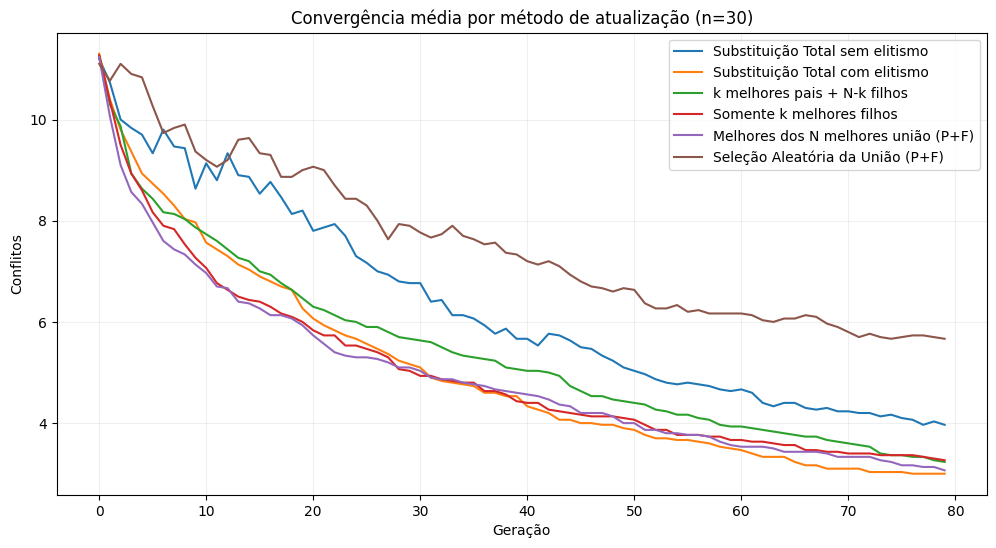

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

n_instancia_alt = 30
qtd_execucoes_alt = 30
individuos_fixo_alt = 5
tamanho_populacao_alt = 50
max_geracoes_alt = 80
taxa_mutacao_alt = 0.05

class AG_N_Rainhas_Alternativo:
    def __init__(self, n, tamanho_populacao=tamanho_populacao_alt, max_geracoes=max_geracoes_alt, taxa_mutacao=taxa_mutacao_alt, metodo_atualizacao=1, k=individuos_fixo_alt,):
        self.n = n
        self.tamanho_populacao = tamanho_populacao
        self.max_geracoes = max_geracoes
        self.taxa_mutacao = taxa_mutacao
        self.metodo_atualizacao = metodo_atualizacao
        self.k = min(max(1, k), self.tamanho_populacao - 1)
        self.populacao = self._inicializar_populacao()

    def _inicializar_populacao(self):
        pop = []
        for _ in range(self.tamanho_populacao):
            individuo = list(range(self.n))
            random.shuffle(individuo)
            pop.append(individuo)
        return pop

    def calcular_aptidao(self, individuo):
        conflitos = 0
        for i in range(len(individuo)):
            for j in range(i + 1, len(individuo)):
                if abs(i - j) == abs(individuo[i] - individuo[j]):
                    conflitos += 1
        return conflitos

    def selecao_torneio(self):
        competidor1 = random.choice(self.populacao)
        competidor2 = random.choice(self.populacao)
        return competidor1 if self.calcular_aptidao(competidor1) < self.calcular_aptidao(competidor2) else competidor2

    def cruzamento(self, pai1, pai2):
        ponto = random.randint(1, self.n - 2)
        return pai1[:ponto] + [gene for gene in pai2 if gene not in pai1[:ponto]]

    def mutacao(self, individuo):
        if random.random() < self.taxa_mutacao:
            idx1, idx2 = random.sample(range(self.n), 2)
            individuo[idx1], individuo[idx2] = individuo[idx2], individuo[idx1]
        return individuo

    def _ordenar_por_aptidao(self, individuos):
        return sorted(individuos, key=self.calcular_aptidao)

    def _atualizar_populacao(self, filhos, aptidoes_atuais):
        N = self.tamanho_populacao
        k = self.k
        pais_ordenados = self._ordenar_por_aptidao(self.populacao)
        filhos_ordenados = self._ordenar_por_aptidao(filhos)

        # substituição total sem elitismo N pais para N filhos
        if self.metodo_atualizacao == 1:
            self.populacao = filhos[:N]

        #substituição total com elitismo melhor pai + N-1 filhos
        elif self.metodo_atualizacao == 2:
            melhor_pai = self.populacao[int(np.argmin(aptidoes_atuais))]
            self.populacao = [melhor_pai] + filhos_ordenados[: N - 1]

        # mantem k melhores pais e inserir N-k filhos
        elif self.metodo_atualizacao == 3:
            self.populacao = pais_ordenados[:k] + filhos[: N - k]

        # insere somente os k melhores filhos substitui os k piores pais
        elif self.metodo_atualizacao == 4:
            self.populacao = pais_ordenados[: N - k] + filhos_ordenados[:k]

        # agrupa  N pais + M filhos e seleciona os N melhores
        elif self.metodo_atualizacao == 5:
            uniao = self.populacao + filhos
            self.populacao = self._ordenar_por_aptidao(uniao)[:N]

        # agrupa N pais + M filhos e seleciona N aleatorios
        elif self.metodo_atualizacao == 6:
            uniao = self.populacao + filhos
            self.populacao = random.sample(uniao, N)

        else:
            raise ValueError(f"Método de atualização inválido: {self.metodo_atualizacao}")

    def executa(self):
        historico_melhor = []

        for _ in range(self.max_geracoes):
            aptidoes_atuais = [self.calcular_aptidao(ind) for ind in self.populacao]
            melhor_valor = min(aptidoes_atuais)
            historico_melhor.append(melhor_valor)

            if melhor_valor == 0:
                break

            filhos = []
            for _ in range(self.tamanho_populacao):
                p1 = self.selecao_torneio()
                p2 = self.selecao_torneio()
                filho = self.cruzamento(p1, p2)
                filhos.append(self.mutacao(filho))

            self._atualizar_populacao(filhos, aptidoes_atuais)

        return historico_melhor[-1], historico_melhor

# auxilio de IA explicado abaixo
def _media_com_padding(curvas):
    max_len = max(len(c) for c in curvas)
    curvas_pad = []
    for c in curvas:
        if len(c) < max_len:
            c = c + [c[-1]] * (max_len - len(c))
        curvas_pad.append(c)
    return np.mean(np.array(curvas_pad), axis=0)

# usei IA nesse ponto tanto para me ajudar a estimar uma média visto q os valores das curvas poderiam ser menores que outros pois convergia mais rapido que as outras dessa forma usei para me ajudar com a ideia de como calcular a media atravez de tamanhos q não sao iguais
def comparar_metodos(n_instancia=n_instancia_alt, qtd_execucoes=qtd_execucoes_alt, k=individuos_fixo_alt,):
    metodos = {
        1: "Substituição Total sem elitismo",
        2: "Substituição Total com elitismo",
        3: "k melhores pais + N-k filhos",
        4: "Somente k melhores filhos",
        5: "Melhores dos N melhores união (P+F)",
        6: "Seleção Aleatória da União (P+F)",
    }

    largura_metodo = max(len(nome) for nome in metodos.values()) + 2
    print(f"\nComparação de métodos de atualização para n={n_instancia}")
    print(f"{'Método':<{largura_metodo}} | {'Sucesso (%)':<12} | {'Média conflitos'}")
    print("-" * (largura_metodo + 33))

    plt.figure(figsize=(12, 6))

    for m_id, m_nome in metodos.items():
        conflitos_finais = []
        curvas = []

        for _ in range(qtd_execucoes):
            ag = AG_N_Rainhas_Alternativo(
                n=n_instancia,
                metodo_atualizacao=m_id,
                k=k,
            )
            final_v, hist = ag.executa()
            conflitos_finais.append(final_v)
            curvas.append(hist)

        taxa_sucesso = (conflitos_finais.count(0) / qtd_execucoes) * 100
        media_conflitos = float(np.mean(conflitos_finais))
        print(f"{m_nome:<{largura_metodo}} | {taxa_sucesso:<12.2f} | {media_conflitos:.2f}")

        media_curva = _media_com_padding(curvas)
        plt.plot(media_curva, label=m_nome)

    plt.title(f"Convergência média por método de atualização (n={n_instancia})")
    plt.xlabel("Geração")
    plt.ylabel("Conflitos")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

comparar_metodos()